In [29]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import toeplitz, solve, pinv
from scipy.signal import lfilter, freqz

# Exercice 4.2.1 — Approximation de Prony : signal à décroissance exponentielle

## Fonction Générale `prony(x, p, q)`

Écrire une fonction qui automatise le calcul de Prony pour tout ordre $(p, q)$ via l'approche matricielle des moindres carrés.

La fonction doit implémenter :

1. **Calcul de $a_p$** (si $p > 0$) : construire $X_q$ en utilisant **toutes les lignes** de $q+1$ à $N-1$ (système sur-déterminé), puis résoudre les équations normales $R_x \mathbf{a}_p = -\mathbf{r}_x$ avec $R_x = X_q^T X_q$ et $\mathbf{r}_x = X_q^T \mathbf{x}_{q+1}$.

2. **Calcul de $b_q$** : extraire les $q+1$ premières lignes de la matrice de convolution et calculer $\mathbf{b}_q = X_{0:q+1} \cdot \mathbf{a}_p$.

3. **Reconstruction et erreur** : réponse impulsionnelle $\hat{x}(n)$ via `lfilter`, puis $E_{ls} = \|x - \hat{x}\|_2$.

**Test :** Appliquer `prony(x, p=1, q=1)` sur le signal $x(n) = 3 \cdot (0.5)^n$ et comparer les coefficients obtenus, la position du pôle et l'erreur $E_{ls}$ avec les résultats du modèle AR(2) de Padé.

> **Ce que l'on attend :** Avec $p=1$, Prony doit retrouver le pôle exact $z = 0.5$ et produire une erreur quasi-nulle — le signal étant une exponentielle pure, un seul pôle suffit à le décrire parfaitement.

In [30]:
def prony(x, p, q):
    """
    Prony approximation: model signal x by an ARMA(p, q) filter H(z) = B(z)/A(z).
    Unlike Padé (exact on the first p+q+1 samples), Prony minimises the
    least-squares error over the WHOLE signal -> robust, no divergence.

    Inputs
    ------
    x : 1-D array, length N        the signal to model
    p : int                        number of poles   (denominator order)
    q : int                        number of zeros   (numerator order)

    Outputs
    -------
    ap   : 1-D array, length p+1   denominator coeffs [1, a1, ..., ap]
    bq   : 1-D array, length q+1   numerator coeffs   [b0, ..., bq]
    epq  : float                   reconstruction error ||x - xhat||_2
    xhat : 1-D array, length N     reconstructed impulse response

    Key points / gotchas
    ---------------------
    - Step 1 differs from Padé: Xq keeps ALL rows (q+1 .. N-1), so the system
      is over-determined (more equations than unknowns) -> least squares.
    - Normal equations turn the tall system into a square p x p one:
          Rx = Xq^T Xq  (autocorrelation),  rx = Xq^T xq_1  (cross-corr)
      then solve Rx @ ap = -rx, like Padé but on Rx instead of Xq.
    - xz : x left-padded with p zeros, so a negative-time index falls on a 0.
    - solve() returns only [a1..ap]; the leading 1 is prepended by hand.
    - Step 2 (zeros) and reconstruction are IDENTICAL to Padé.
    - p == 0 (pure MA): no poles, ap = [1], step 1 is skipped.
    - delta : unit impulse (Kronecker) [1, 0, ...]; its filter response = xhat.
    """
    N = len(x)
    xz = np.concatenate([np.zeros(p), x])    # left-pad: negative-time samples = 0

    # --- Step 1: denominator ap (poles), least-squares over all rows ---
    if p > 0:
        xq_1   = x[q+1 : N]                   # right-hand side, length N-1-q
        Xq_col = x[q   : N-1]                 # first column of Xq (tall: N-1-q rows)
        Xq_row = xz[q+1 : q+p+1][::-1]        # first row of Xq, reversed, p values
        Xq = toeplitz(Xq_col, Xq_row)        # (N-1-q) x p over-determined matrix

        Rx = Xq.T @ Xq                       # p x p autocorrelation (square)
        rx = Xq.T @ xq_1                     # p cross-correlation vector
        ap_tail = solve(Rx, -rx)             # solves [a1..ap] (normal equations)
        ap = np.concatenate(([1.0], ap_tail))  # prepend the fixed 1
    else:                                     # pure MA: no poles, A(z) = 1
        ap = np.array([1.0])

    # --- Step 2: numerator bq (zeros), same as Padé ---
    X0_col = x[0 : q + 1]                     # first column of X0, q+1 values
    X0_row = np.zeros(p + 1)                  # first row: [x(0), 0, ..., 0]
    X0_row[0] = x[0]
    X0 = toeplitz(X0_col, X0_row)            # (q+1) x (p+1) Toeplitz matrix
    bq = X0 @ ap                             # b = X0 @ ap (no system to solve)

    # --- Reconstruction: impulse response of filter bq/ap ---
    delta = np.zeros(N)                       # unit impulse [1, 0, 0, ...]
    delta[0] = 1.0
    xhat = lfilter(bq, ap, delta)            # impulse response = reconstruction
    epq  = np.linalg.norm(x - xhat)          # L2 error over all N samples

    return ap, bq, epq, xhat

## Méthode de Shanks

### Principe

La méthode de Shanks est une amélioration de Prony pour l'estimation du numérateur $b_q$. Là où Prony calcule $b_q$ uniquement sur les $q+1$ premiers échantillons, Shanks optimise $b_q$ **sur l'ensemble du signal** au sens des moindres carrés.

### Algorithme en deux phases

**Phase 1 — Estimation de $a_p$ (identique à Prony) :**  
On résout les équations normales pour fixer les pôles du système. Cette étape est commune aux deux méthodes.

**Phase 2 — Estimation optimale de $b_q$ (spécifique à Shanks) :**  
On calcule d'abord la réponse impulsionnelle $g(n)$ du filtre tout-pôle $1/A(z)$ en appliquant $A(z)$ à une impulsion $\delta(n)$. On construit ensuite la matrice de convolution de $g(n)$ et on résout le système des moindres carrés :

$$\min_{\mathbf{b}_q} \|x - G \mathbf{b}_q\|^2 \quad \Rightarrow \quad \mathbf{b}_q = (G^T G)^{-1} G^T \mathbf{x}$$

> **Avantage de Shanks sur Prony :**  
> En optimisant $b_q$ globalement, Shanks produit une erreur quadratique totale plus faible — particulièrement visible sur des signaux longs ou des filtres à réponse impulsionnelle étendue comme le sinc. Le coût est une étape supplémentaire de résolution par moindres carrés.

In [31]:
def shanks(x, p, q):
    """
    Shanks' method: like Prony for the poles, but the zeros bq are ALSO
    optimised by least squares over the whole signal (Prony fixes bq only
    on the first q+1 samples). Same ap as Prony, better bq.

    Inputs
    ------
    x : 1-D array, length N        the signal to model
    p : int                        number of poles   (denominator order)
    q : int                        number of zeros   (numerator order)

    Outputs
    -------
    ap   : 1-D array, length p+1   denominator coeffs [1, a1, ..., ap] (from Prony)
    bq   : 1-D array, length q+1   numerator coeffs, least-squares optimal
    epq  : float                   reconstruction error ||x - xhat||_2
    xhat : 1-D array, length N     reconstructed signal G @ bq

    Key points / gotchas
    ---------------------
    - Step 1: poles come straight from Prony (identical ap).
    - Step 2: H(z) = B(z) * (1/A(z)). The 1/A(z) part is fixed, so we look for
      the B(z) whose convolution with g(n) best matches x.
      g(n) = impulse response of the all-pole filter 1/A(z).
      G = convolution matrix of g(n); solve min ||x - G bq||^2.
    - pinv(G) @ x : least-squares solution for bq (equiv. to solve(G.T@G, G.T@x)).
    """
    ap, _, _, _ = prony(x, p, q)             # poles: identical to Prony
    N_sig = len(x)

    delta = np.zeros(N_sig)                  # unit impulse [1, 0, 0, ...]
    delta[0] = 1.0
    gn = lfilter([1.0], ap, delta)           # g(n) = impulse response of 1/A(z)

    G = toeplitz(gn, np.zeros(q + 1))        # convolution matrix of g(n), N x (q+1)
    bq = pinv(G) @ x                         # least-squares optimal numerator
    xhat = G @ bq                            # reconstruction = g(n) convolved with bq
    epq = np.linalg.norm(x - xhat)           # L2 error over all N samples

    return ap, bq, epq, xhat

# Exercice 4.2.1 — Approximation de Prony : signal à décroissance exponentielle

## 1. Introduction et définition du signal

L'objectif est de tester l'approximation de Prony sur un signal à décroissance exponentielle non oscillatoire, défini sur $N = 41$ échantillons :

$$x(0) = 1, \qquad x(n) = 3 \cdot (0.5)^n \quad \text{pour } n = 1, \dots, N-1$$

> **Différence entre Padé et Prony :**  
> - **Padé** impose une coïncidence exacte sur les $p+q+1$ premiers échantillons — c'est une méthode d'interpolation exacte sur une fenêtre courte.  
> - **Prony** cherche les coefficients ARMA qui minimisent l'erreur au sens des moindres carrés sur **l'ensemble des $N$ échantillons** — c'est une méthode d'approximation globale, plus robuste sur des signaux longs ou bruités.

> **Ce que l'on attend :** Le signal étant une exponentielle pure de pôle $z = 0.5$, Prony devrait retrouver ce pôle exactement avec un modèle AR(1), et l'erreur devrait être quasi-nulle.

In [32]:
# Paramètres du signal
N = 41
n = np.arange(N)
xn = np.zeros(N)
xn[0] = 1.0
xn[1:] = 3 * (0.5)**n[1:]
print("Premiers échantillons du signal xn :")
print(xn[:8])

Premiers échantillons du signal xn :
[1.        1.5       0.75      0.375     0.1875    0.09375   0.046875
 0.0234375]


## 4.2.2. Test avec un modèle AR(2)

On teste un modèle purement auto-régressif avec $p = 2$ pôles et $q = 0$ zéros.

La démarche est identique à Padé en ce qui concerne la structure matricielle, mais la différence clé est dans l'extraction de $X_q$ :

1. **Construire** la matrice de convolution complète $X$ à partir de $x(n)$.

2. **Extraire** $X_q$ et $\mathbf{x}_{q+1}$ — ici on utilise **toutes les lignes disponibles** de $q+1$ à $N-1$ (et non seulement $p$ lignes comme dans Padé). Le système est donc **sur-déterminé** : plus d'équations que d'inconnues.

3. **Résoudre au sens des moindres carrés** via la pseudo-inverse :
$$\mathbf{a}_p = -(X_q^T X_q)^{-1} X_q^T \, \mathbf{x}_{q+1}$$

> **Pourquoi la pseudo-inverse ?**  
> Contrairement à Padé qui résout un système carré exact, Prony minimise l'erreur quadratique $\|X_q \mathbf{a}_p + \mathbf{x}_{q+1}\|^2$ sur l'ensemble du signal. La solution est unique si $X_q$ est de rang plein, et robuste aux perturbations numériques.

In [33]:
p = 2
q = 0

# Construction de la matrice Xq (similaire à convmtx en Matlab)
first_col = xn
first_row = np.zeros(p + 1)
first_row[0] = xn[0]
X_full = toeplitz(first_col, first_row)

# Extraction de Xq et xq+1 pour les équations de Prony
Xq = X_full[q : N-1, 0:p]
xq_1 = xn[q+1 : N]

# Affichage de Xq et xq_1 pour vérification
print("Matrice Xq :")
print(Xq[0:5, :]) # Affiche les 5 premières lignes de Xq
print("Vecteur xq_1 :")
print(xq_1[0:5]) # Affiche les 5 premières valeurs de xq_1

# Calcul des coefficients ap (système : Xq * ap = -xq_1)
ap_tail = -pinv(Xq) @ xq_1
ap = np.concatenate(([1.0], ap_tail))
print(f"Coefficients du dénominateur ap : {ap}")

Matrice Xq :
[[1.     0.    ]
 [1.5    1.    ]
 [0.75   1.5   ]
 [0.375  0.75  ]
 [0.1875 0.375 ]]
Vecteur xq_1 :
[1.5     0.75    0.375   0.1875  0.09375]
Coefficients du dénominateur ap : [ 1.         -1.07142857  0.42857143]


## 4.2.3. Calcul par les équations normales ($R_x$ et $r_x$)

Plutôt que de résoudre directement par pseudo-inverse, on peut reformuler le problème des moindres carrés sous la forme des **équations normales** :

$$R_x \, \mathbf{a}_p = -\mathbf{r}_x$$

où :
- $R_x = X_q^T X_q$ — matrice d'autocorrélation (taille $p \times p$), symétrique définie positive
- $\mathbf{r}_x = X_q^T \, \mathbf{x}_{q+1}$ — vecteur de corrélation croisée (taille $p$)

> **Lien avec Yule-Walker :** Pour un processus stationnaire, $R_x$ est une matrice de Toeplitz et les équations normales deviennent exactement les équations de Yule-Walker. Ici, sur un signal fini déterministe, $R_x$ n'est pas strictement de Toeplitz mais la structure est similaire.

> **Avantage numérique :** Résoudre $R_x \mathbf{a}_p = -\mathbf{r}_x$ via `solve` est plus stable que d'inverser explicitement $X_q$ — on exploite la symétrie et le conditionnement de $R_x$ plutôt que de manipuler la grande matrice $X_q$ directement.

In [34]:
# Calcul de la matrice Rx et du vecteur rx
Rx = Xq.T @ Xq
rx = Xq.T @ xq_1
print("Matrice d'autocorrélation Rx :")
print(Rx)
print("\nVecteur rx :")
print(rx)
# Résolution des coefficients ap (coefficients 1 à p)
ap_tail = -solve(Rx, rx)
ap = np.concatenate(([1.0], ap_tail))
print(f"\nCoefficients ap calculés via Rx : {ap}")

Matrice d'autocorrélation Rx :
[[4. 3.]
 [3. 4.]]

Vecteur rx :
[3.  1.5]

Coefficients ap calculés via Rx : [ 1.         -1.07142857  0.42857143]


## 4.2.4. Calcul de la réponse impulsionnelle et de l'erreur

Une fois $a_p$ obtenu par les équations normales, on reconstruit le signal estimé $\hat{x}(n)$ comme la réponse impulsionnelle du filtre $H(z) = b_0 / A(z)$, où pour un modèle AR pur ($q = 0$) :

$$b_0 = x(0)$$

La réponse impulsionnelle est ensuite obtenue en appliquant le filtre à une impulsion de Dirac $\delta(n)$.

L'erreur globale de Prony est mesurée sur l'ensemble des $N$ échantillons :

$$E_{ls} = \|x - \hat{x}\|_2 = \sqrt{\sum_{n=0}^{N-1}(x(n) - \hat{x}(n))^2}$$

> **Interprétation :** Contrairement à Padé où l'erreur est nulle sur les $p+q+1$ premiers échantillons puis peut exploser, Prony répartit l'erreur uniformément sur tout le signal. Pour un signal exponentiel pur, l'erreur de Prony doit être très faible même avec un modèle AR(1) — le pôle $z = 0.5$ est retrouvé exactement.

5 premier valeur de l'erreur : [0.         0.42857143 0.03061224 0.06341108 0.16196377]
Erreur Least Squares (Els) : 0.54772


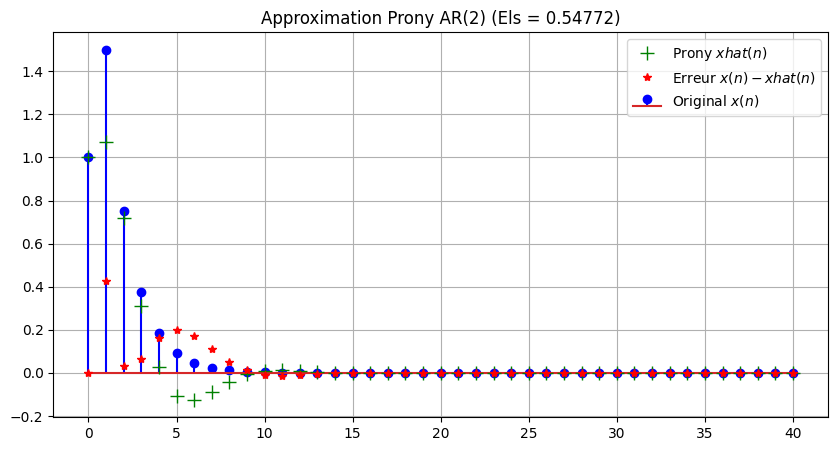

In [35]:
# Pour un AR(2), bq est x(0) si q=0
bq = np.array([xn[0]])

# Reconstruction du signal (Réponse impulsionnelle)
xhat = lfilter(bq, ap, np.eye(1, N)[0])

# Calcul de l'erreur
error = xn - xhat
Els = np.linalg.norm(error)
print(f"5 premier valeur de l'erreur : {error[:5]}")
print(f"Erreur Least Squares (Els) : {Els:.5f}")
plt.figure(figsize=(10, 5))
plt.stem(n, xn, linefmt='b-', markerfmt='bo', label='Original $x(n)$')
plt.plot(n, xhat, 'g+', markersize=10, label='Prony ${xhat}(n)$')
plt.plot(n, error, 'r*', label='Erreur $x(n) - {xhat}(n)$')
plt.title(f'Approximation Prony AR(2) (Els = {Els:.5f})')
plt.legend()
plt.grid(True)
plt.show()

# Exercice 4.3.1 — Modélisation de Prony : signal oscillant amorti

## 1. Introduction

La méthode de **Prony** est une technique de modélisation paramétrique qui représente un signal comme une somme de $p$ exponentielles complexes :

$$x(n) = \sum_{i=1}^{p} A_i z_i^n$$

où :
- $p$ — ordre du modèle (nombre de pôles)
- $A_i$ — amplitudes complexes (encodent amplitude et phase de chaque composante)
- $z_i = e^{s_i \Delta t}$ — pôles complexes, avec $s_i = \sigma_i + j\omega_i$

> **Interprétation des pôles $z_i$ :**
> - $|z_i| < 1$ → composante amortie (décroissance exponentielle)
> - $|z_i| = 1$ → composante sinusoïdale pure (non amortie)
> - $|z_i| > 1$ → composante divergente
> - $\angle z_i = \omega_i \Delta t$ → fréquence de la composante

> **Avantage sur Fourier :** La méthode de Prony estime des fréquences **continues** (non contraintes à la grille FFT) ainsi que leurs facteurs d'amortissement — ce qui est impossible avec une DFT classique. Elle est particulièrement adaptée aux signaux résonants, vibratoires ou aux transitoires amortis.

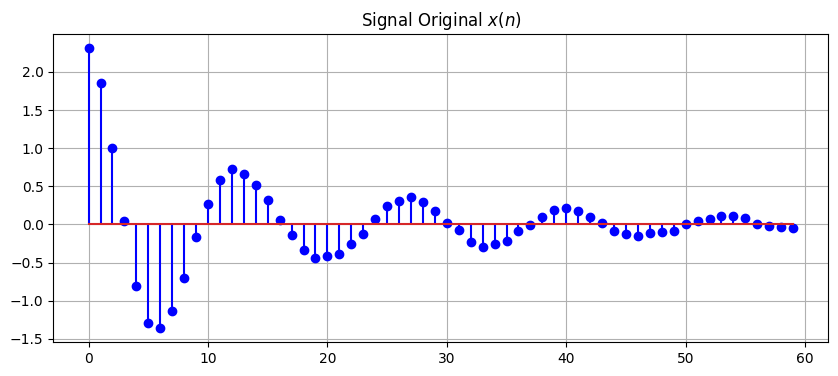

In [36]:
# Fixer la seed pour la reproductibilité
np.random.seed(42)
# Paramètres
N = 60
n = np.arange(N)
# Génération d'un signal test (2 sinusoïdes amorties)
F1 = 0.075 # Fréquence normalisée de la première sinusoïde
F2 = 0.2
# Fréquence normalisée de la deuxième sinusoïde
x = 1.5 * (0.95**n) * np.cos(F1 *2* np.pi * n) + 0.8 * (0.9**n) * np.cos(F2* np.pi * n)
xn = x + 0.02 * np.random.randn(N) # Ajout de bruit

plt.figure(figsize=(10, 4))
plt.stem(n, xn, linefmt='b-', markerfmt='bo', label='Signal avec bruit $x(n)$')
plt.title("Signal Original $x(n)$")
plt.grid(True)
plt.show()

## 4.3.2. Estimation des coefficients $a_k$

On suppose que le signal admet une **prédiction linéaire** à partir de ses échantillons passés :

$$x(n) = -\sum_{k=1}^{p} a_k\, x(n-k)$$

Les coefficients $a_k$ sont les coefficients du dénominateur $A(z) = 1 + \sum_{k=1}^p a_k z^{-k}$, dont les racines sont précisément les pôles $z_i$ du modèle de Prony.

**Résolution :** On construit une matrice de Toeplitz à partir des données observées et on résout le système sur-déterminé au sens des **moindres carrés** — c'est exactement ce que fait la fonction `prony(x, p, q)` avec $p = 4$, $q = 0$.

> **Pourquoi $p=4$, $q=0$ ?**  
> Le signal est une combinaison d'exponentielles amorties et de cosinus. Chaque cosinus amorti correspond à une **paire de pôles complexes conjugués** — donc 2 pôles par composante oscillante. Avec $p=4$ on peut modéliser 2 composantes oscillantes (ou 4 exponentielles réelles). Le modèle AR pur ($q=0$) suffit car il n'y a pas de zéros à modéliser.

> **Étape suivante :** Une fois $a_k$ estimés, les pôles $z_i$ sont obtenus en calculant les **racines du polynôme** $A(z)$ — c'est le cœur de la méthode de Prony.

In [37]:
p = 4 # Ordre du modèle (2 sinusoïdes = 4 pôles complexes)
ap2, bq2, epq2, _ = prony(xn, 4, 4)
print(f"ARMA(2,2) -> ap: {ap2}")
print(f"bq: {bq2}, Erreur: {epq2
:.4e}")
a_coeffs = ap2
print(f"Coefficients a_k estimés : {a_coeffs}")

ARMA(2,2) -> ap: [ 1.         -1.05361845  0.11337234  0.16754013  0.14571672]
bq: [ 2.30993428 -0.58437813 -0.67778008 -0.41490216 -0.10021885], Erreur: 7.8363e-01
Coefficients a_k estimés : [ 1.         -1.05361845  0.11337234  0.16754013  0.14571672]


## 4.3.3. Étape 2 — Calcul des pôles complexes $z_i$

Les pôles sont les racines du polynôme caractéristique $A(z)$ :

$$A(z) = 1 + a_1 z^{-1} + a_2 z^{-2} + \dots + a_p z^{-p} = 0$$

En pratique, on calcule les racines du vecteur de coefficients $[1, a_1, a_2, \dots, a_p]$ via `np.roots(ap)`.

Chaque pôle $z_i$ donne accès à :
- **Fréquence :** $f_i = \frac{\angle z_i}{2\pi \Delta t}$
- **Amortissement :** $\sigma_i = \frac{\ln|z_i|}{\Delta t}$

> **Lecture des pôles dans le plan complexe :**
> - Les pôles apparaissent par **paires conjuguées** $z_i, z_i^*$ pour un signal réel
> - Plus $|z_i|$ est proche de 1, moins la composante est amortie
> - $\angle z_i$ donne directement la pulsation normalisée $\omega_i \Delta t$

> **Vérification :** Pour un signal bien modélisé, les pôles estimés doivent correspondre aux pôles théoriques du signal — c'est le test de validation de la méthode de Prony.

Pôles du système en module et phase : [ 0.8024825 +0.42040196j  0.8024825 -0.42040196j -0.27567328+0.31867309j
 -0.27567328-0.31867309j]
Modules des pôles : [0.90593376 0.90593376 0.4213648  0.4213648 ]
Phases des pôles : [  27.6489997   -27.6489997   130.86197072 -130.86197072]
Fréquences des pôles : [ 0.07680278 -0.07680278  0.36350547 -0.36350547]


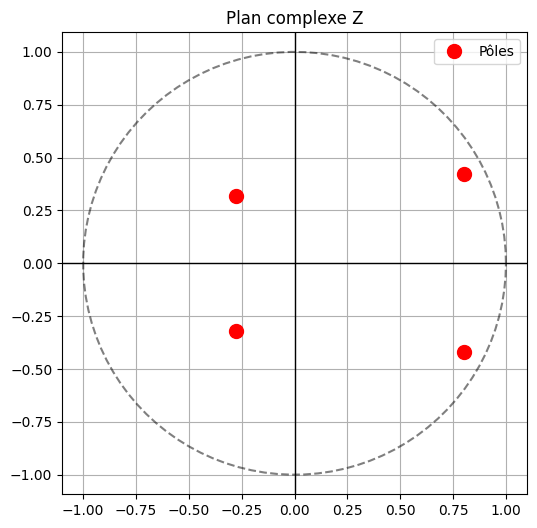

In [38]:
# Calcul des racines
poles = np.roots(a_coeffs)
ModulesPoles = np.abs(poles)
PhasesPoles = np.angle(poles, deg=True)
FreqPoles = PhasesPoles / 360 # Convertir les phases en fréquences normalisées
print(f"Pôles du système en module et phase : {poles}")
print(f"Modules des pôles : {ModulesPoles}")
print(f"Phases des pôles : {PhasesPoles}")
print(f"Fréquences des pôles : {FreqPoles}")

# Affichage du plan complexe
plt.figure(figsize=(6, 6))
t = np.linspace(0, 2*np.pi, 100)
plt.plot(np.cos(t), np.sin(t), 'k--', alpha=0.5)
plt.plot(np.real(poles), np.imag(poles), 'ro', markersize=10, label="Pôles")
plt.axhline(0, color='black', lw=1)
plt.axvline(0, color='black', lw=1)
plt.title("Plan complexe Z")
plt.legend()
plt.axis('equal')
plt.grid(True)
plt.show()

## 4.3.4. Étape 3 — Estimation des amplitudes $A_i$

Une fois les pôles $z_i$ connus, les amplitudes $A_i$ sont obtenues en résolvant un système linéaire. Le signal s'écrit :

$$x(n) = \sum_{i=1}^{p} A_i z_i^n \quad \Rightarrow \quad V \mathbf{A} = \mathbf{x}$$

où $V$ est la matrice de **Vandermonde** de taille $N \times p$ :

$$V = \begin{bmatrix} z_1^0 & z_2^0 & \cdots & z_p^0 \\ z_1^1 & z_2^1 & \cdots & z_p^1 \\ \vdots & \vdots & \ddots & \vdots \\ z_1^{N-1} & z_2^{N-1} & \cdots & z_p^{N-1} \end{bmatrix}$$

Le système est sur-déterminé ($N \gg p$), donc on résout au sens des **moindres carrés** via la pseudo-inverse :

$$\mathbf{A} = (V^H V)^{-1} V^H \mathbf{x}$$

> **Les amplitudes $A_i$ sont complexes** — leur module donne l'amplitude de chaque composante, leur argument donne la phase initiale. Pour un signal réel, les amplitudes apparaissent également par paires conjuguées $A_i, A_i^*$.

> **En pratique :** `np.linalg.lstsq(V, x)` résout ce système de façon numériquement stable, sans calculer explicitement la pseudo-inverse.

In [39]:
# Matrice de Vandermonde
V = np.vander(poles, N, increasing=True).T
#print("Matrice de Vandermonde V :")
#print(V[:5, :]) # Affiche les 5 premières lignes de V

# Résolution pour les amplitudes complexes A_i
A_complex, _, _, _ = np.linalg.lstsq(V, x, rcond=None)
Amod = np.abs(A_complex)
Aphase = np.angle(A_complex, deg=True)

print(f"Amplitudes complexes : {A_complex}")
print(f"Modules des amplitudes : {Amod}")
print(f"Phases des amplitudes : {Aphase}")

Amplitudes complexes : [ 1.26895817+0.14383174j  1.26895817-0.14383174j -0.11262649+0.14571451j
 -0.11262649-0.14571451j]
Modules des amplitudes : [1.27708356 1.27708356 0.18416689 0.18416689]
Phases des amplitudes : [   6.46666659   -6.46666659  127.70135864 -127.70135864]


## 4.3.5. Reconstruction et résidus

Une fois les amplitudes $A_i$ et les pôles $z_i$ estimés, le signal reconstruit est :

$$\hat{x}(n) = \text{Re}\left(\sum_{i=1}^{p} A_i z_i^n\right)$$

La partie réelle est nécessaire car pour un signal réel, les pôles et amplitudes complexes conjugués se combinent pour donner une somme réelle — mais des erreurs numériques introduisent de petites parties imaginaires résiduelles.

**Résidu :** L'erreur de modélisation est calculée sur l'ensemble des $N$ échantillons :

$$e(n) = x(n) - \hat{x}(n), \qquad E_{ls} = \|e\|_2$$

> **Interprétation des résidus :**
> - $E_{ls} \approx 0$ → le modèle capture parfaitement la structure du signal
> - Résidus structurés (périodiques) → composantes manquantes, ordre $p$ trop faible
> - Résidus aléatoires → bruit non modélisable, ordre $p$ suffisant

> **Différence avec Prony AR :** La reconstruction ici est faite directement via la somme d'exponentielles $A_i z_i^n$, sans passer par `lfilter` — les deux approches sont équivalentes mais celle-ci est plus explicite sur la nature physique de chaque composante.

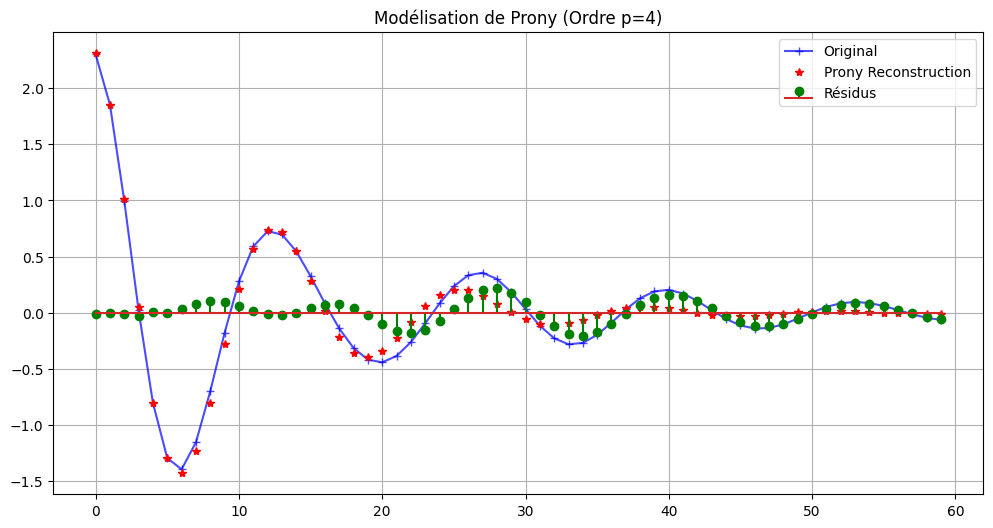

Erreur Quadratique Moyenne (MSE) : 9.77e-03


In [40]:
# Reconstruction
#x_hat = np.real(V @ A_complex)
x_hat = lfilter(bq2, ap2, np.eye(1, N)[0]) # Reconstruction avec les modules et les coefficients ap


# Graphique de comparaison
plt.figure(figsize=(12, 6))
plt.plot(n, x, 'b-+', label="Original", alpha=0.7)
plt.plot(n, x_hat, 'r*', label="Prony Reconstruction")
plt.stem(n, x - x_hat, linefmt='g-', markerfmt='go', label="Résidus")
plt.title(f"Modélisation de Prony (Ordre p={p})")
plt.legend()
plt.grid(True)
plt.show()
mse = np.mean((x - x_hat)**2)
print(f"Erreur Quadratique Moyenne (MSE) : {mse:.2e}")

# Exemple 4.4.1 — Synthèse de filtre par approximation de Prony

## 1. Définition du filtre idéal

L'objectif est le même qu'en 4.1.6 : synthétiser un filtre rationnel $H(z) = B(z)/A(z)$ approchant un **filtre passe-bas idéal à phase linéaire** :

$$H(jf) = \begin{cases} e^{-j n_d 2\pi f} & \text{pour } |f| < F_p \\ 0 & \text{pour } F_p < |f| < 0.5 \end{cases}$$

La réponse impulsionnelle cible est un **sinc décalé** de $n_d$ échantillons :

$$h(n) = 2F_p\,\text{sinc}(2F_p(n - n_d)) = \frac{\sin\!\left((n-n_d)\pi/2\right)}{(n-n_d)\pi}$$

> **Différence clé avec Padé (4.1.6) :**  
> - **Padé** coïncide exactement avec $h(n)$ sur les $p+q+1$ premiers échantillons, mais peut diverger au-delà.  
> - **Prony** minimise l'erreur quadratique sur **l'ensemble des $N$ échantillons** du sinc — l'approximation est globalement meilleure, au prix de ne plus être exacte sur aucun échantillon particulier.

On utilisera les mêmes paramètres qu'en 4.1.6 pour permettre une comparaison directe entre les deux méthodes :
- $N = 100$, $F_p = 0.25$, $n_d = 5$
- Modèle ARMA$(6, 6)$

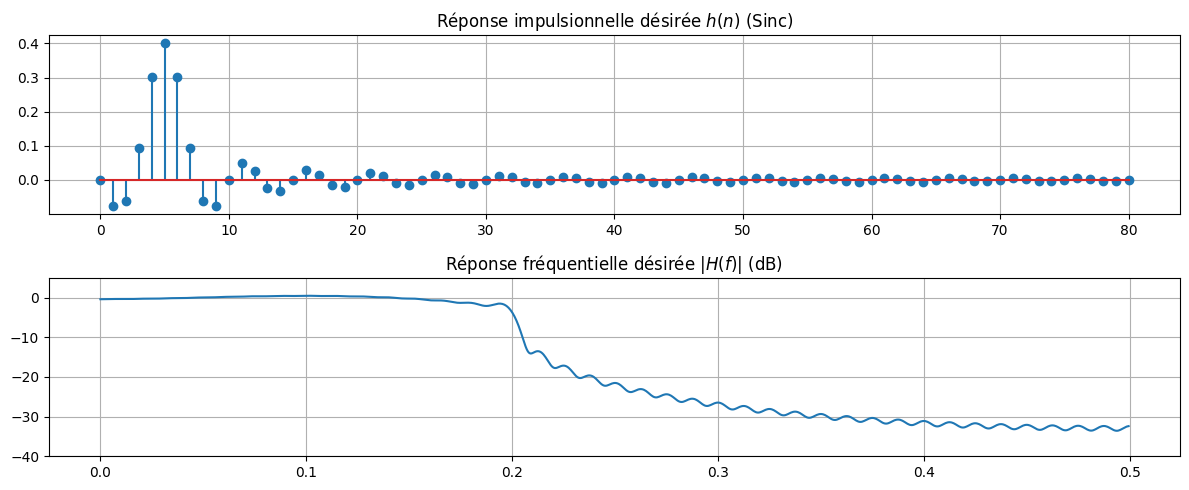

In [41]:
# Paramètres du design
N = 81
Fp = 0.20
nd = 5
n = np.arange(N)

# Génération de la réponse impulsionnelle désirée (Target)
# Note: np.sinc(x) calcule sin(pi*x)/(pi*x)
hn = 2 * Fp * np.sinc(2 * Fp * (n - nd))

# Visualisation du filtre idéal
plt.figure(figsize=(12, 5))
plt.subplot(2, 1, 1)
plt.stem(n, hn)
plt.title("Réponse impulsionnelle désirée $h(n)$ (Sinc)")
plt.grid(True)

plt.subplot(2, 1, 2)
w, H_ideal = freqz(hn, 1, worN=1024)
plt.plot(w/(2*np.pi), 20*np.log10(np.abs(H_ideal)))
plt.title("Réponse fréquentielle désirée $|H(f)|$ (dB)")
plt.ylim([-40, 5])
plt.grid(True)
plt.tight_layout()
plt.show()

## 4.4.2. Fonction Prony avec équations normales

Pour estimer les paramètres ARMA$(p, q)$ du filtre, on applique la méthode de Prony via les équations normales :

$$R_x \, \mathbf{a}_p = -\mathbf{r}_x$$

avec $R_x = X_q^T X_q$ et $\mathbf{r}_x = X_q^T \mathbf{x}_{q+1}$, construites sur la fenêtre $[q+1, N-1]$ — soit l'ensemble du signal disponible. Une fois $a_p$ obtenu, $b_q$ est calculé sur les $q+1$ premières lignes comme en 4.2.5.

## 4.4.4. Comparaison des designs : FIR vs IIR (Prony & Shanks)

On compare trois approches pour approximer le filtre passe-bas idéal, avec un nombre total de paramètres comparable :

**FIR — MA(10) :** $p=0,\ q=10$  
11 coefficients, pas de pôles. Réponse impulsionnelle finie, toujours stable. L'approximation est locale — les 11 premiers échantillons du sinc sont reproduits exactement, mais la coupure fréquentielle sera peu sélective.

**IIR Prony — ARMA(5,5) :** $p=5,\ q=5$  
11 paramètres également, mais répartis entre pôles et zéros. Le numérateur $b_q$ est estimé sur les $q+1$ premiers échantillons seulement — approximation moins précise globalement mais rapide à calculer.

**IIR Shanks — ARMA(5,5) :** $p=5,\ q=5$  
Mêmes pôles que Prony, mais $b_q$ optimisé sur l'ensemble des $N$ échantillons. On attend la meilleure approximation des trois en termes d'erreur quadratique globale et de sélectivité fréquentielle.

> **Ce que l'on compare :**
> - Les réponses impulsionnelles $\hat{h}(n)$ vs le sinc cible
> - Les réponses en fréquence $|H(e^{j2\pi f})|$ vs le gabarit rectangulaire idéal
> - Les erreurs $E_{ls}$ pour quantifier la qualité de chaque approximation

> **Conclusion attendue :** Shanks $<$ Prony $<$ FIR en termes d'erreur — un filtre IIR avec optimisation globale du numérateur surpasse les approches locales avec le même nombre de paramètres.

Erreur FIR (q=10) : 0.0965
Erreur Prony (5,5) : 0.0649
Erreur Shanks (5,5) : 0.0645


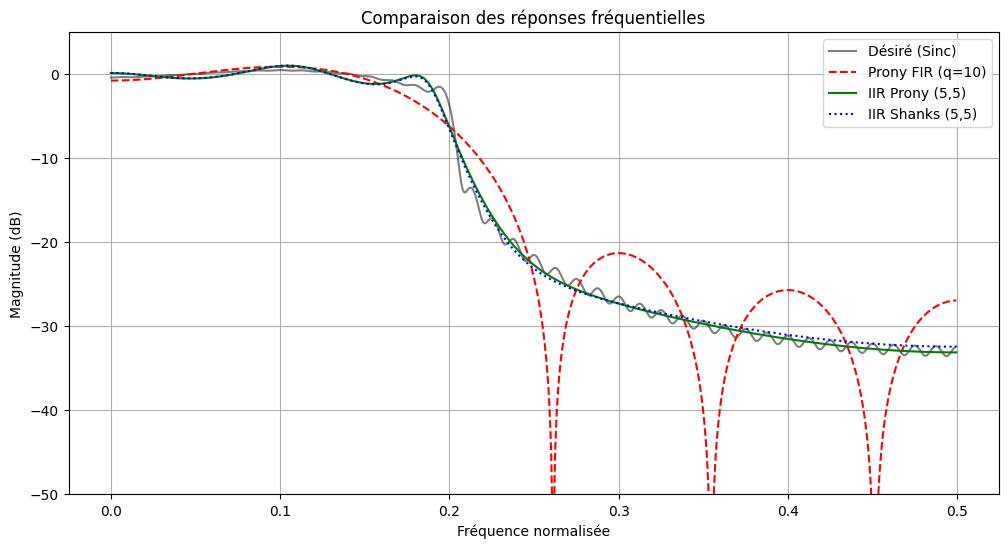

In [42]:
# Calcul des trois modèles
ap_fir, bq_fir, err_fir, x_fir = prony(hn, 0, 10)
ap_pr, bq_pr, err_pr, x_pr = prony(hn, 5, 5)
ap_sh, bq_sh, err_sh, x_sh = shanks(hn, 5, 5)

# Affichage des erreurs L2
print(f"Erreur FIR (q=10) : {err_fir:.4f}")
print(f"Erreur Prony (5,5) : {err_pr:.4f}")
print(f"Erreur Shanks (5,5) : {err_sh:.4f}")

# Visualisation fréquentielle comparative
w, H_fir = freqz(bq_fir, ap_fir, worN=1024)
w, H_pr = freqz(bq_pr, ap_pr, worN=1024)
w, H_sh = freqz(bq_sh, ap_sh, worN=1024)
plt.figure(figsize=(12, 6))
plt.plot(w/(2*np.pi), 20*np.log10(np.abs(H_ideal)), 'k', label='Désiré (Sinc)',alpha=0.5)
plt.plot(w/(2*np.pi), 20*np.log10(np.abs(H_fir)), 'r--', label='Prony FIR (q=10)')
plt.plot(w/(2*np.pi), 20*np.log10(np.abs(H_pr)), 'g', label='IIR Prony (5,5)')
plt.plot(w/(2*np.pi), 20*np.log10(np.abs(H_sh)), 'b:', label='IIR Shanks (5,5)')
plt.title("Comparaison des réponses fréquentielles")
plt.xlabel("Fréquence normalisée")
plt.ylabel("Magnitude (dB)")
plt.ylim([-50, 5])
plt.legend()
plt.grid(True)
plt.show()

## 4.4.5. Comparaison avec la méthode de Prony

**Précision :** Pour un modèle ARMA(5,5), Shanks produit une erreur légèrement plus faible ($E_{ls} = 0.0645$) que Prony ($E_{ls} = 0.0649$). L'amélioration est modeste ici car le signal est court — elle devient plus significative sur des signaux longs.

**Coefficients $b_q$ :** Les numérateurs diffèrent entre les deux méthodes — Prony utilise uniquement les $q+1 = 6$ premiers échantillons pour estimer $b_q$, tandis que Shanks intègre l'information de l'ensemble des $N$ échantillons via la matrice de convolution de $g(n)$.

**Stabilité :** Les deux méthodes partagent les mêmes pôles (même $a_p$). La stabilité du filtre — pôles à l'intérieur du cercle unité — dépend donc uniquement de la première étape commune (Prony AR). Si les pôles sont stables, les deux filtres le sont.

> **Quand privilégier Shanks ?**  
> Shanks est préférable lorsque :
> - Le signal est long (plus d'information exploitable pour $b_q$)
> - La fidélité de la réponse impulsionnelle reconstruite est critique
> - L'ordre $q$ est élevé (l'estimation locale de Prony devient alors insuffisante)
>
> Pour des signaux courts ou des modèles d'ordre faible, les deux méthodes donnent des résultats très proches.